## Apply AIMS4PT Cpx to Merapi

This notebook applies the AIMS4PT clinopyroxene thermobarometry workflow to the Merapi case study, including data preparation, P-T calculation, equilibrium checks, and figure export.


## 1. Setup and Shared Model Pools

### Module and Data Imports

In [1]:
from pathlib import Path
import sys

def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")

PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache"
IMAGES_DIR = PAPER_DIR / ".images"
DATA_DIR = PAPER_DIR / "data"
for _dir in (CACHE_DIR, IMAGES_DIR, DATA_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2
# %matplotlib widget
%matplotlib inline

import pandas as pd
import numpy as np
import sys
import os
import time
import importlib
import matplotlib.pyplot as plt
from aims4pt.model_tools.model_registry import  get_models_initial_pools, print_all_registered_thermobarometry, ALL_MODELS_MODULES
from aims4pt.toolkit_utils import get_file_path
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)



calculate_shap = False # make sure this to False when not needed, as it takes time and memory

timestamp = time.strftime("%Y%m%d_%H%M")
timestamp = "20260513_1427"


In [2]:


#col names for unseen_experiments_df
cpx_names = ['SiO2_cpx', 'TiO2_cpx', 'Al2O3_cpx',
       'Fe2O3_cpx', 'Cr2O3_cpx', 'FeO_cpx', 'MnO_cpx', 'MgO_cpx', 'NiO_cpx',
       'CoO_cpx', 'CaO_cpx', 'Na2O_cpx', 'K2O_cpx', 'P2O5_cpx',]
liq_names = ['SiO2_liq', 'TiO2_liq', 'Al2O3_liq',
       'Fe2O3_liq', 'Cr2O3_liq', 'FeO_liq', 'MnO_liq', 'MgO_liq', 'NiO_liq',
       'CoO_liq', 'CaO_liq', 'Na2O_liq', 'K2O_liq', 'P2O5_liq']
P_col = 'P (kbar)'
T_col = 'T (C)'


### Initial Thermobarometry Model Pools

In [3]:
P_model_pool = get_models_initial_pools("P", "both" , False) # get all P models including cpx_only and cpx_liq
P_model_names = list(model.model_name for model in P_model_pool)
T_model_pool = get_models_initial_pools("T", "both" , False) # get all T models including cpx_only and cpx_liq
T_model_names = list(model.model_name for model in T_model_pool)


[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[skipped] Error initializing model <class 'aims4pt.model_tools.Neave_Putirka_17.Neave_Putirka_17'> with T: Pu08_eq33_T, P: eq1_P - Neave_Putirka_17 only supports pressure (P) calculations, not temperature (T) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [4]:
P_model_dict = {model.model_name: model for model in P_model_pool}
T_model_dict = {model.model_name: model for model in T_model_pool}

## 2. Loading and Preparing Merapi Data

In [5]:
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
cpx_path = os.path.join(DATA_DIR, "merapi_cpx.xlsx")
liq_path = os.path.join(DATA_DIR, "merapi_liq.xlsx")
cpx_raw = pd.read_excel(cpx_path)
liq_raw = pd.read_excel(liq_path)
cpx_raw.columns = cpx_raw.columns.str.strip()  
liq_raw.columns = liq_raw.columns.str.strip()
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
cpx_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO',
       'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO']
# Set water content (following Scruggs and Putirka, 2018)
# Liq_Comp['H2O_Liq']=Liq_Comp['SiO2_Liq']*0.06995+0.383
cpx_raw.keys()

Index(['Sample_id', 'crystal_id', 'crystal#', 'Eruption', 'Source', 'Rim/core',
       'SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O',
       'Cr2O3', 'NiO', 'F', 'Cl', 'TOTAL', '(Ca+Fe+Mg)/Si', 'cpx/opx',
       'Equilibrium', 'Pressure (Agreda-López et al., 2024)',
       'max eq melt Mg# (kd = 0.28+0.08)', 'min eq melt Mg# (kd = 0.28-0.08)'],
      dtype='object')

Before cleaning, number of cpx samples: 470
After cpx classification, number of cpx samples: 470
After checking total, number of cpx samples: 455
After cpx stoichiometry check, number of cpx samples: 455


,Sample_id,crystal_id,crystal#,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,...,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx,Equilibrium,"Pressure (Agreda-López et al., 2024)",max eq melt Mg# (kd = 0.28+0.08),min eq melt Mg# (kd = 0.28-0.08)
0,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,52.321400,0.335623,1.479980,8.761620,...,0.000000,NaN,NaN,98.828300,0.972547,NaN,False,NaN,0.521797,0.377413
1,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,52.150900,0.450180,2.140010,8.173920,...,0.002265,NaN,NaN,99.291200,0.976964,NaN,False,NaN,0.534907,0.389853
2,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,53.144500,0.359789,2.118480,8.699070,...,0.012777,NaN,NaN,99.641400,0.942052,NaN,False,NaN,0.517487,0.373364
3,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,50.286900,0.783383,3.851290,9.425180,...,0.000000,NaN,NaN,99.613500,1.000066,NaN,True,2.589693,0.477223,0.336494
4,Un 95 2006cpx1-80W,2006cpx1-80,2,2006,LI thesis,NaN,50.215500,0.655089,3.577590,8.785490,...,0.000000,NaN,NaN,98.521700,0.993763,NaN,True,2.165689,0.497077,0.354463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2010-cpx1 Line 056,2010-cpx1,50,2010,"Li et al., 2021",core,52.201905,0.462875,2.137423,8.738641,...,NaN,0.000000,0.000000,100.000000,0.991379,NaN,False,NaN,0.529786,0.384971
451,2010-cpx1 Line 057,2010-cpx1,50,2010,"Li et al., 2021",core,52.245775,0.388605,1.976162,8.708968,...,NaN,0.000000,0.007029,100.002008,0.997148,NaN,False,NaN,0.535274,0.390203
452,2010-cpx1 Line 058,2010-cpx1,50,2010,"Li et al., 2021",core,52.417017,0.491529,1.687247,8.550592,...,NaN,0.026081,0.003009,100.012037,0.998169,NaN,False,NaN,0.544007,0.398600
453,2010-cpx1 Line 059,2010-cpx1,50,2010,"Li et al., 2021",core,52.677229,0.366991,1.580267,8.373609,...,NaN,0.000000,0.001003,100.000000,0.994099,NaN,False,NaN,0.549339,0.403768


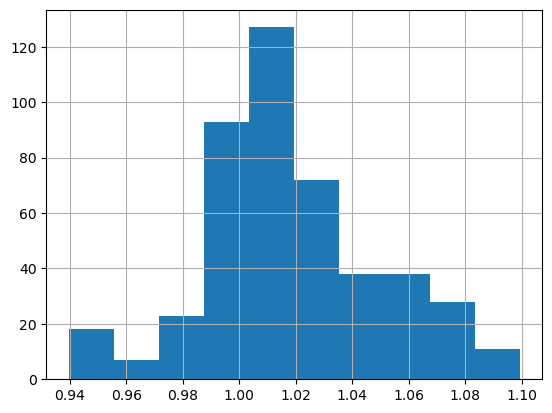

In [6]:
# clean cpx
print("Before cleaning, number of cpx samples:", len(cpx_raw))

# negative value to zero
cpx_raw[cpx_cols] = cpx_raw[cpx_cols].clip(lower=0)
# check if cpx
from aims4pt.data_tools.compositions import pyroxene_classification, cpx_stoichiometry_check

cpx_class = pyroxene_classification(cpx_raw[cpx_cols])
cpx_clean0 = cpx_raw[cpx_class=="Clinopyroxene"].reset_index(drop=True)
print("After cpx classification, number of cpx samples:", len(cpx_clean0))
# total 

cpx_total = cpx_raw['TOTAL']
cpx_clean1 = cpx_clean0[(cpx_total>98)&(cpx_total<102)].reset_index(drop=True)
print("After checking total, number of cpx samples:", len(cpx_clean1))

# '(Ca+Fe+Mg)/Si'
cpx_clean1['(Ca+Fe+Mg)/Si'], stio_mask = cpx_stoichiometry_check(cpx_clean1[cpx_cols])
cpx_clean1['(Ca+Fe+Mg)/Si'].hist()
cpx_clean2 = cpx_clean1[stio_mask].reset_index(drop=True)
print("After cpx stoichiometry check, number of cpx samples:", len(cpx_clean2))
cpx_clean2

In [7]:
cpx_06_input = cpx_clean2[cpx_clean2["Eruption"]==2006].reset_index(drop=True)
cpx_06_input


,Sample_id,crystal_id,crystal#,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,...,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx,Equilibrium,"Pressure (Agreda-López et al., 2024)",max eq melt Mg# (kd = 0.28+0.08),min eq melt Mg# (kd = 0.28-0.08)
0,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,52.321400,0.335623,1.479980,8.761620,...,0.000000,NaN,NaN,98.828300,0.972547,NaN,False,NaN,0.521797,0.377413
1,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,52.150900,0.450180,2.140010,8.173920,...,0.002265,NaN,NaN,99.291200,0.976964,NaN,False,NaN,0.534907,0.389853
2,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,53.144500,0.359789,2.118480,8.699070,...,0.012777,NaN,NaN,99.641400,0.942052,NaN,False,NaN,0.517487,0.373364
3,Un 96 2006cpx1-test,2006cpx1-test,1,2006,LI thesis,NaN,50.286900,0.783383,3.851290,9.425180,...,0.000000,NaN,NaN,99.613500,1.000066,NaN,True,2.589693,0.477223,0.336494
4,Un 95 2006cpx1-80W,2006cpx1-80,2,2006,LI thesis,NaN,50.215500,0.655089,3.577590,8.785490,...,0.000000,NaN,NaN,98.521700,0.993763,NaN,True,2.165689,0.497077,0.354463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,2006trav2n Line 031,2006trav2n,19,2006,"Li et al., 2021",core,52.001848,0.305273,2.386954,7.489230,...,NaN,0.022092,0.000000,100.009038,1.004588,NaN,False,NaN,0.561799,0.415974
161,2006trav2n Line 032,2006trav2n,19,2006,"Li et al., 2021",core,51.827991,0.431817,2.625805,7.776692,...,NaN,0.017951,0.003989,100.008975,1.002159,NaN,False,NaN,0.548072,0.402538
162,2006trav2n Line 033,2006trav2n,19,2006,"Li et al., 2021",core,51.222576,0.673837,3.012330,7.860767,...,NaN,0.004984,0.000000,100.001994,1.009589,NaN,False,NaN,0.540617,0.395330
163,2006trav2n Line 034,2006trav2n,19,2006,"Li et al., 2021",core,51.001196,0.488290,3.414012,7.953301,...,NaN,0.000000,0.000000,100.000000,1.014761,NaN,False,NaN,0.535094,0.390031


In [8]:
cpx_10_input = cpx_clean2[cpx_clean2["Eruption"]==2010].reset_index(drop=True)
cpx_10_input

,Sample_id,crystal_id,crystal#,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,...,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx,Equilibrium,"Pressure (Agreda-López et al., 2024)",max eq melt Mg# (kd = 0.28+0.08),min eq melt Mg# (kd = 0.28-0.08)
0,Un 169 2010-pair2-72-CORE2-Cpx,2010-pair2-72-CORE-Cpx,20,2010,LI thesis,NaN,51.640700,0.340871,1.608540,9.066680,...,0.000368,NaN,NaN,98.706000,0.992560,NaN,False,NaN,0.513230,0.369385
1,Un 183 2010-Cpx-square-71S,2010-Cpx-square-71,22,2010,LI thesis,NaN,51.629500,0.375859,1.644280,8.783130,...,0.000000,NaN,NaN,99.032000,1.001765,NaN,False,NaN,0.522665,0.378231
2,Un 185 2010-Cpx-square-CORE,2010-Cpx-square-CORE,23,2010,LI thesis,NaN,51.941600,0.320407,1.289180,8.869380,...,0.000000,NaN,NaN,98.887900,0.997027,NaN,False,NaN,0.524331,0.379803
3,Un 273 2010-Pair1-cpx-E2,2010-Pair1-cpx,24,2010,LI thesis,NaN,47.673200,1.189990,5.892850,9.575310,...,0.010384,NaN,NaN,98.934300,1.036143,NaN,True,2.930556,0.448929,0.311571
4,Un 274 2010-Pair1-67S-cpx,2010-Pair1-67-cpx,25,2010,LI thesis,NaN,52.626700,0.404880,1.763390,8.795380,...,0.004714,NaN,NaN,100.044000,0.984384,NaN,False,NaN,0.524699,0.380150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,2010-cpx1 Line 056,2010-cpx1,50,2010,"Li et al., 2021",core,52.201905,0.462875,2.137423,8.738641,...,NaN,0.000000,0.000000,100.000000,0.991379,NaN,False,NaN,0.529786,0.384971
286,2010-cpx1 Line 057,2010-cpx1,50,2010,"Li et al., 2021",core,52.245775,0.388605,1.976162,8.708968,...,NaN,0.000000,0.007029,100.002008,0.997148,NaN,False,NaN,0.535274,0.390203
287,2010-cpx1 Line 058,2010-cpx1,50,2010,"Li et al., 2021",core,52.417017,0.491529,1.687247,8.550592,...,NaN,0.026081,0.003009,100.012037,0.998169,NaN,False,NaN,0.544007,0.398600
288,2010-cpx1 Line 059,2010-cpx1,50,2010,"Li et al., 2021",core,52.677229,0.366991,1.580267,8.373609,...,NaN,0.000000,0.001003,100.000000,0.994099,NaN,False,NaN,0.549339,0.403768


## 3. Cpx-Liquid Pairing

### Pairing Setup

In [9]:
liq_cols = ['SiO2', 'TiO2',
       'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']


In [10]:
liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)

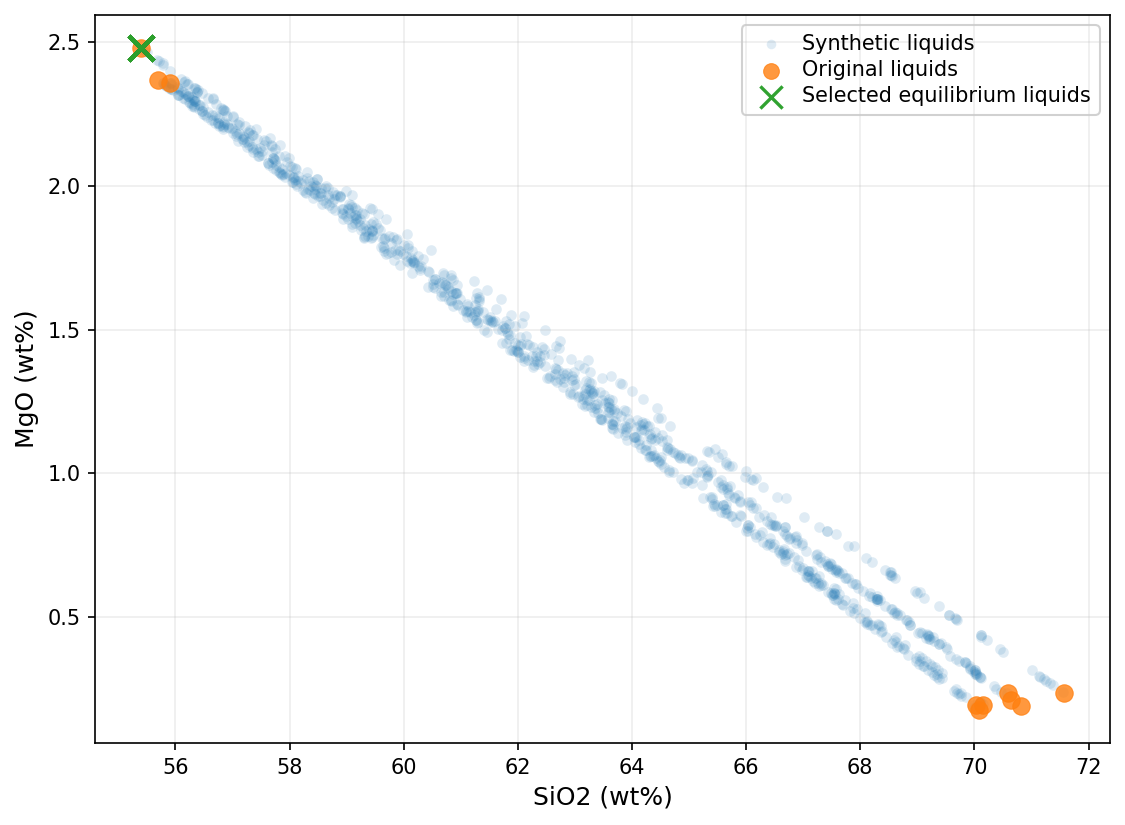

In [11]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd


# res_06 = pair_mineral_liquid_by_kd(
#     cpx_06_input, liq_2006[liq_cols],
#     kd=0.28, error=0.08,
#     interpolate_liq=True,
#     interp_mode="between",
#     n_synth=1000,
#     random_state=42
# )
res_06 = pair_mineral_liquid_by_kd(
    X_mine=cpx_06_input,
    X_liq=liq_2006[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2006[liq_2006['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2006[liq_2006['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)

paired_cpx_06, paired_liq_06 = res_06.cleaned_minerals, res_06.cleaned_liquids
paired_cpx_06_pass = paired_cpx_06[res_06.pairs_pass_mask].reset_index(drop=True)
paired_liq_06_pass = paired_liq_06[res_06.pairs_pass_mask].reset_index(drop=True)




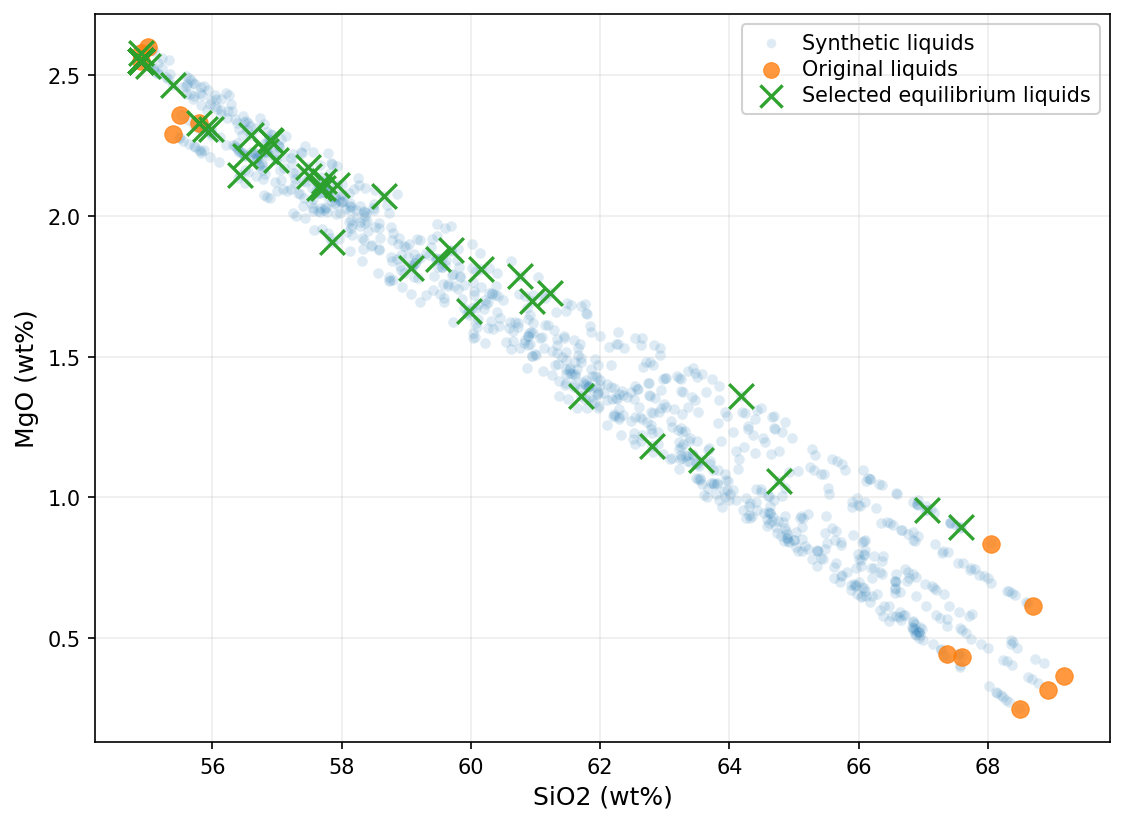

In [12]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd


# res_10 = pair_mineral_liquid_by_kd(
#     cpx_10_input, liq_2010[liq_cols],
#     kd=0.28, error=0.08,
#     interpolate_liq=True,
#     interp_mode="between",
#     n_synth=2000,
#     random_state=42
# )

res_10 = pair_mineral_liquid_by_kd(
    X_mine=cpx_10_input,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)





## 4. Cpx-Liquid Thermobarometry

### Cpx-Liquid Setup

In [13]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_liq_pool = [model for model in P_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_P_06 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_P_10 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"

from aims4pt.reporting.excel import report_excel
report_excel(
    workflow_obj=workflow_cpx_liq_P_06,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_P_10,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_P_workflow_cpx_liq_P_20260513_1427.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_P_workflow_cpx_liq_P_20260513_1427.pkl


In [14]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_liq_pool = [model for model in T_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_T_06 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_T_10 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_liq_T_06,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_T_10,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_T_workflow_cpx_liq_T_20260513_1427.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_T_workflow_cpx_liq_T_20260513_1427.pkl


## 5. Cpx-Only Thermobarometry

### Cpx-Only Setup

In [15]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_only_pool = [model for model in P_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_P_06 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_P_10 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_P_06,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_P_10,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_P_workflow_cpx_only_P_20260513_1427.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_P_workflow_cpx_only_P_20260513_1427.pkl


In [16]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_only_pool = [model for model in T_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_T_06 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_T_10 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_T_06,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_T_10,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_T_workflow_cpx_only_T_20260513_1427.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_T_workflow_cpx_only_T_20260513_1427.pkl


## 6. Liquid Thermobarometry

### Data Preparation

In [17]:
glass_mineral  = {
    'ol': 0, #
    'opx': 1,
    'cpx': 1,
    'plag': 1,
    'amph': 1,
    'ox': 1,
    'bt': 0, #
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

whole_rock_mineral_2  = {
    'ol': 1,
    'opx': 1,
    'cpx': 1,
    'plag': 0,
    'amph': 0,
    'ox': 0,
    'bt': 0,
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

glass_mineral_df = pd.DataFrame([glass_mineral])
whole_rock_mineral_df_2 = pd.DataFrame([whole_rock_mineral_2])  


# liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
# liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)
liq_2006_glass = liq_2006[liq_2006["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2006_bulk = liq_2006[liq_2006["glass/bulk"]=="bulk"].reset_index(drop=True)
liq_2010_glass = liq_2010[liq_2010["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2010_bulk = liq_2010[liq_2010["glass/bulk"]=="bulk"].reset_index(drop=True)



In [18]:
from aims4pt.model_tools.local_models.WandB24_melt import WandB24_melt


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


### Glass Calculations

In [19]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",4) # 4 is the maximum
P_06_glass = P_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))

P_06_glass

0    2.571405
1    2.617135
2    2.597763
3    2.613756
4    2.385761
5    2.834220
6    2.701609
Name: P_kbar, dtype: float64

In [20]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_glass = P_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))

P_10_glass

0    3.624881
1    4.176075
2    3.883335
3    4.475628
4    3.583497
5    4.521359
6    4.835092
Name: P_kbar, dtype: float64

In [21]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 4)
T_06_glass = T_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))
T_06_glass

0    896.734320
1    895.690263
2    900.823777
3    887.202860
4    912.499878
5    890.807947
6    933.464901
Name: T_C, dtype: float64

In [22]:
T_10_glass = T_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))
T_10_glass

0    908.453739
1    944.435455
2    905.130439
3    939.026039
4    940.386646
5    928.743372
6    964.146544
Name: T_C, dtype: float64

### Whole-Rock Calculations

In [23]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",3)
P_06_bulk = P_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))

P_06_bulk

0    6.282600
1    6.306187
2    6.437876
Name: P_kbar, dtype: float64

In [24]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_bulk = P_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))

P_10_bulk

0    6.530688
1    6.752381
2    6.587118
3    6.815809
4    6.808471
5    6.788134
Name: P_kbar, dtype: float64

In [25]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 3)
T_06_bulk = T_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))
T_06_bulk

0    1055.818273
1    1053.651935
2    1063.067838
Name: T_C, dtype: float64

In [26]:
T_10_bulk = T_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))
T_10_bulk

0    1061.506121
1    1066.706402
2    1065.909294
3    1077.922585
4    1073.216512
5    1073.105220
Name: T_C, dtype: float64

## 7. Merapi compositions comparison with the independent dataset


In [ ]:
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from aims4pt.visualization.composition_plot import plot_glass_TAS_diagram
from paper.scripts.figure_helpers import save_figure_pdf_png


def _find_oxide_column(df, oxide, phase=None):
    """Return an oxide column using the notebook naming convention first."""
    candidates = []
    if phase is not None:
        candidates.extend([
            f"{oxide}_{phase}",
            f"{oxide}_{phase.lower()}",
            f"{oxide}_{phase.upper()}",
            f"{oxide}_{phase.capitalize()}",
        ])
    candidates.extend([oxide, oxide.lower(), oxide.upper()])
    for col in candidates:
        if col in df.columns:
            return col

    def _norm(name):
        return ''.join(ch.lower() for ch in str(name) if ch.isalnum())

    normalized = {_norm(col): col for col in df.columns}
    for col in candidates:
        key = _norm(col)
        if key in normalized:
            return normalized[key]
    raise KeyError(f"Could not find {oxide} column for phase={phase}. Available columns: {list(df.columns)}")


def _composition_frame(cpx_df, liq_df):
    """Build a common composition table from paired cpx and liquid dataframes."""
    return pd.DataFrame({
        "SiO2_liq": pd.to_numeric(liq_df[_find_oxide_column(liq_df, "SiO2", "liq")], errors="coerce"),
        "Na2O_liq": pd.to_numeric(liq_df[_find_oxide_column(liq_df, "Na2O", "liq")], errors="coerce"),
        "K2O_liq": pd.to_numeric(liq_df[_find_oxide_column(liq_df, "K2O", "liq")], errors="coerce"),
        "MgO_liq": pd.to_numeric(liq_df[_find_oxide_column(liq_df, "MgO", "liq")], errors="coerce"),
        "SiO2_cpx": pd.to_numeric(cpx_df[_find_oxide_column(cpx_df, "SiO2", "cpx")], errors="coerce"),
        "Na2O_cpx": pd.to_numeric(cpx_df[_find_oxide_column(cpx_df, "Na2O", "cpx")], errors="coerce"),
        "Al2O3_cpx": pd.to_numeric(cpx_df[_find_oxide_column(cpx_df, "Al2O3", "cpx")], errors="coerce"),
    }).dropna(how="all")


def _load_independent_compositions():
    """Return the cleaned independent experimental cpx-liquid dataset."""
    if "unseen_experiments_df" in globals():
        independent_df = unseen_experiments_df.copy()
    elif {"training_unseen_id", "testing_unseen_id", "cpx_unseen", "liq_unseen"}.issubset(globals()):
        ids = list(training_unseen_id) + list(testing_unseen_id)
        independent_df = pd.concat([cpx_unseen.loc[ids], liq_unseen.loc[ids]], axis=1).reset_index(drop=True)
    else:
        independent_df = pd.read_excel(DATA_DIR / "independent_data_final.xlsx")
    if len(independent_df) != 293:
        raise ValueError(f"Expected 293 cleaned independent equilibrium pairs, got {len(independent_df)}.")
    return _composition_frame(independent_df, independent_df)


def _valid_xy(df, x_col, y_col):
    """Return finite x and y arrays for plotting."""
    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def _kde_contours(ax, df, x_col, y_col, xlim, ylim):
    """Draw grey 2D KDE contours enclosing approximately 95, 80, and 50 percent density mass."""
    x, y = _valid_xy(df, x_col, y_col)
    in_view = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])
    x, y = x[in_view], y[in_view]
    if len(x) < 8 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return None
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return None

    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 140),
        np.linspace(ylim[0], ylim[1], 140),
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    flat = zz.ravel()
    order = np.argsort(flat)[::-1]
    cdf = np.cumsum(flat[order]) / np.sum(flat[order])
    levels = []
    for mass in (0.95, 0.80, 0.50):
        levels.append(flat[order[np.searchsorted(cdf, mass)]])
    levels = np.unique(np.sort(levels))
    if len(levels) == 0:
        return None
    return ax.contour(xx, yy, zz, levels=levels, colors="0.45", linewidths=1.0, alpha=0.8, zorder=1)


def _fraction_above(df, col, upper):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    return 0.0 if values.empty else float((values > upper).mean())


def _next_tick(value, step=1.0, max_value=None):
    limit = np.ceil(value / step) * step
    if max_value is not None:
        limit = min(limit, max_value)
    return float(limit)


def _percentile_limits_if_clipped(dfs, col, base_limits, margin_frac=0.08):
    values = pd.concat([pd.to_numeric(df[col], errors="coerce") for df in dfs]).dropna()
    if values.empty:
        return base_limits
    if values.between(base_limits[0], base_limits[1]).all():
        return base_limits
    lo, hi = np.nanpercentile(values, [1, 99])
    pad = (hi - lo) * margin_frac if hi > lo else 0.2
    return (float(np.floor((lo - pad) * 10) / 10), float(np.ceil((hi + pad) * 10) / 10))


def _style_axes(ax):
    """Apply the compact manuscript-style axis formatting."""
    ax.tick_params(axis="both", labelsize=8, width=0.8, length=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def _panel_label(ax, label):
    """Add a bold panel label in axes coordinates."""
    ax.text(0.03, 0.96, label, transform=ax.transAxes, ha="left", va="top", fontsize=10, fontweight="bold")


independent_comp = _load_independent_compositions()
merapi_2006_comp = _composition_frame(paired_cpx_06_pass, paired_liq_06_pass)
merapi_2010_comp = _composition_frame(paired_cpx_10_pass, paired_liq_10_pass)

if len(merapi_2006_comp) != 42 or len(merapi_2010_comp) != 104:
    raise ValueError(f"Unexpected retained Merapi counts: 2006 n={len(merapi_2006_comp)}, 2010 n={len(merapi_2010_comp)}")

independent_subset = independent_comp.sample(n=min(100, len(independent_comp)), random_state=42)
for df in (independent_comp, independent_subset, merapi_2006_comp, merapi_2010_comp):
    df["Na2O_K2O_liq"] = df["Na2O_liq"] + df["K2O_liq"]

fig7, axes7 = plt.subplots(2, 2, figsize=(7.3, 6.5), dpi=200)
axes7 = axes7.ravel()
all_comp = [independent_comp, merapi_2006_comp, merapi_2010_comp]

mgo_ylim = (0, 12)
if max(_fraction_above(df, "MgO_liq", 12) for df in all_comp) > 0.03:
    max_mgo = max(pd.to_numeric(df["MgO_liq"], errors="coerce").max() for df in all_comp)
    mgo_ylim = (0, _next_tick(max_mgo + 0.5, step=1.0, max_value=15))

cpx_na_xlim = _percentile_limits_if_clipped(all_comp, "SiO2_cpx", (44, 56))
cpx_na_ylim = _percentile_limits_if_clipped(all_comp, "Na2O_cpx", (0, 2.0))
cpx_al_xlim = _percentile_limits_if_clipped(all_comp, "SiO2_cpx", (44, 56))
cpx_al_ylim = _percentile_limits_if_clipped(all_comp, "Al2O3_cpx", (0, 14))

panel_specs = [
    ("Liquid TAS", "SiO2_liq", "Na2O_K2O_liq", (40, 80), (0, 18), "SiO$_2$ (wt%)", "Na$_2$O + K$_2$O (wt%)", "(a)"),
    ("Liquid MgO-SiO2", "SiO2_liq", "MgO_liq", (40, 80), mgo_ylim, "SiO$_2$ (wt%)", "MgO (wt%)", "(b)"),
    ("Cpx Na2O-SiO2", "SiO2_cpx", "Na2O_cpx", cpx_na_xlim, cpx_na_ylim, "SiO$_2$ (wt%)", "Na$_2$O$_{cpx}$ (wt%)", "(c)"),
    ("Cpx Al2O3-SiO2", "SiO2_cpx", "Al2O3_cpx", cpx_al_xlim, cpx_al_ylim, "SiO$_2$ (wt%)", "Al$_2$O$_3$$_{cpx}$ (wt%)", "(d)"),
]

for ax, (title, x_col, y_col, xlim, ylim, xlabel, ylabel, label) in zip(axes7, panel_specs):
    if title == "Liquid TAS":
        tas_template = independent_comp[["SiO2_liq", "Na2O_liq", "K2O_liq"]].iloc[0:0].copy()
        plot_glass_TAS_diagram(
            tas_template,
            model="LeMaitreCombined",
            axes=ax,
            color="0.80",
            linewidth=0.6,
            plot_alkaline_boundary=True,
        )
        for line in ax.lines:
            line.set_zorder(0)
            line.set_alpha(0.8)
            line.set_color("0.78")
            line.set_linewidth(0.6)

    _kde_contours(ax, independent_comp, x_col, y_col, xlim, ylim)
    ax.scatter(
        independent_subset[x_col], independent_subset[y_col],
        color="0.65", alpha=0.25, s=10, edgecolor="none", zorder=2,
    )
    ax.scatter(
        merapi_2006_comp[x_col], merapi_2006_comp[y_col],
        marker="o", color="#1f77b4", s=28, alpha=0.9,
        edgecolor="0.2", linewidth=0.4, zorder=4,
    )
    ax.scatter(
        merapi_2010_comp[x_col], merapi_2010_comp[y_col],
        marker="D", color="#d62728", s=28, alpha=0.9,
        edgecolor="0.2", linewidth=0.4, zorder=5,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    _panel_label(ax, label)
    _style_axes(ax)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="0.65", markeredgecolor="none", markersize=5, alpha=0.45, label="Independent dataset"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#1f77b4", markeredgecolor="0.2", markeredgewidth=0.4, markersize=5.5, label="Merapi 2006 (n = 42)"),
    Line2D([0], [0], marker="D", linestyle="none", markerfacecolor="#d62728", markeredgecolor="0.2", markeredgewidth=0.4, markersize=5.5, label="Merapi 2010 (n = 104)"),
]
fig7.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=8)
fig7.tight_layout(rect=(0, 0, 1, 0.96))

fig7_paths = save_figure_pdf_png(fig7, IMAGES_DIR, "Fig7_Merapi_compositions_comparison", dpi=600)
print(f"Independent experimental pairs: n={len(independent_comp)}")
print(f"Retained Merapi 2006 pairs: n={len(merapi_2006_comp)}")
print(f"Retained Merapi 2010 pairs: n={len(merapi_2010_comp)}")
print("Saved Figure 7:", fig7_paths)


Figure 7 compares the retained Merapi equilibrium clinopyroxene-liquid pairs with the cleaned independent experimental dataset. The comparison is intended to show broad compositional overlap and does not replace model-specific OOD filtering.


## 8. Merapi Plots and Comparison Figures

### Plotting Setup

In [27]:


df = pd.DataFrame({
    "min km": [1.5, 1.5,2, 0 , 10, 25],
    "max km": [2.5, 2.5,3, 4, 15, 45],
    "uncertainty": [1, 0.5, np.nan, 5, 5, 5],
})

from aims4pt.data_tools.crust import kbar_to_km_multilayer, km_to_kbar_multilayer
densities_kg_m3=[2242, 2900]
layer_boundaries_km=[10]

min_kbar = km_to_kbar_multilayer(df["min km"], densities_kg_m3, layer_boundaries_km)
max_kbar = km_to_kbar_multilayer(df["max km"], densities_kg_m3, layer_boundaries_km)
df["min kbar"] = min_kbar
df["max kbar"] = max_kbar
df

,min km,max km,uncertainty,min kbar,max kbar
0,1.5,2.5,1.0,0.329910,0.549851
1,1.5,2.5,0.5,0.329910,0.549851
2,2.0,3.0,NaN,0.439880,0.659821
3,0.0,4.0,5.0,0.000000,0.879761
4,10.0,15.0,5.0,2.199402,3.621852
5,25.0,45.0,5.0,6.466752,12.156552


In [28]:

from aims4pt.model_tools.ModelManager import ModelManager
from aims4pt.visualization.thermobarometry_plot import (
    ThermobarometryWorkflowBundle,
    plot_ranked_thermobarometry_literature_comparison,
    plot_ranked_thermobarometry_summary,
)
from paper.scripts.figure_helpers import save_figure_pdf_png

T_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_T.xlsx")
P_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_P.xlsx")

P_lit_raw = pd.read_excel(P_LIT_PATH)
T_lit_raw = pd.read_excel(T_LIT_PATH)
P_lit_raw = P_lit_raw[P_lit_raw["plot"] == True].reset_index(drop=True)
T_lit_raw = T_lit_raw[T_lit_raw["plot"] == True].reset_index(drop=True)

densities_kg_m3 = [2242, 2900]
layer_boundaries_km = [10]


def _get_model_name(pool, T_P, cpx_only, aliases):
    """Return the model_name for the first matching alias."""
    for alias in aliases:
        model = ModelManager.get_model(
            pool,
            model_name=alias,
            T_P=T_P,
            cpx_only=cpx_only,
            exact=False,
            raise_if_empty=False,
        )
        if model is not None:
            return model.model_name
    raise ValueError(f"No model matched aliases: {aliases}")


def _get_model_names(pool, T_P, cpx_only, alias_groups):
    return [_get_model_name(pool, T_P, cpx_only, aliases) for aliases in alias_groups]


T_cols_liq = _get_model_names(
    T_model_pool,
    "T",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)
P_cols_liq = _get_model_names(
    P_model_pool,
    "P",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Neave & Putirka"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)

P_cols_only = _get_model_names(
    P_model_pool,
    "P",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Putirka, 2008 eq32d_T; eq32b_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)
T_cols_only = _get_model_names(
    T_model_pool,
    "T",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)

cpx_only = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_only_P_06,
    pressure_2010=workflow_cpx_only_P_10,
    temperature_2006=workflow_cpx_only_T_06,
    temperature_2010=workflow_cpx_only_T_10,
)

cpx_liq = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_liq_P_06,
    pressure_2010=workflow_cpx_liq_P_10,
    temperature_2006=workflow_cpx_liq_T_06,
    temperature_2010=workflow_cpx_liq_T_10,
)

liquid_results = {
    "P": {
        "2006": {"glass": P_06_glass, "bulk": P_06_bulk},
        "2010": {"glass": P_10_glass, "bulk": P_10_bulk},
    },
    "T": {
        "2006": {"glass": T_06_glass, "bulk": T_06_bulk},
        "2010": {"glass": T_10_glass, "bulk": T_10_bulk},
    },
}

# 2010 reservoir depth ranges. These values are explicit for easy later editing.
MERAPI_2010_RESERVOIR_BANDS = [
    {
        "label": "<4 km conduit",
        "min_depth_km": 0,
        "max_depth_km": 4,
        "color": "#C8D7EB",
        "alpha": 0.22,
    },
    {
        "label": "4-10 km upper-crustal",
        "min_depth_km": 4,
        "max_depth_km": 10,
        "color": "#E9D8A6",
        "alpha": 0.24,
        "hatch": "///",
        "edgecolor": "#B08D2D",
        "linestyle": "--",
    },
    {
        "label": "11-19 km mid-crustal",
        "min_depth_km": 11,
        "max_depth_km": 19,
        "color": "#B7D7B0",
        "alpha": 0.22,
    },
    {
        "label": ">25 km lower-crustal",
        "min_depth_km": 25,
        "max_depth_km": 37,
        "color": "#D9C2DD",
        "alpha": 0.22,
    },
]

figs = plot_ranked_thermobarometry_summary(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    liquid_results=None,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    show=False,
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
)
save_figure_pdf_png(figs["this_study"][0], IMAGES_DIR, "fig_8_Merapi_P_T")
save_figure_pdf_png(figs["literature_comparison"][0], IMAGES_DIR, "fig_9_Merapi_different_constraints")

fig_s9, axes_s9 = plot_ranked_thermobarometry_literature_comparison(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=liquid_results,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
)
save_figure_pdf_png(
    fig_s9,
    IMAGES_DIR,
    "fig_s_Merapi_different_constraints_with_liquid_thermobarometer",
)

plt.show()


C:\Users\13493\AppData\Local\Temp\ipykernel_18616\2801423407.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [29]:
P_model_names

['Putirka, 2008 eq32d_T; eq32a_P (cpx_only)',
 'Putirka, 2008 eq32d_T; eq32b_P (cpx_only)',
 'Petrelli et al., 2020 (cpx_only)',
 'Higgins et al., 2021 (cpx_only)',
 'Jorgenson et al., 2022 (cpx_only)',
 'Ágreda-López et al., 2024 (cpx_only)',
 'Wang et al., 2021 (cpx_only)',
 'Chicchi et al., 2023 (cpx_only)',
 'Putirka, 2008 eq33_T; eq31_P (cpx_liq)',
 'Neave & Putirka, 2017 Pu08_eq33_T; eq1_P (cpx_liq) (cpx_liq)',
 'Petrelli et al., 2020 (cpx_liq)',
 'Jorgenson et al., 2022 (cpx_liq)',
 'Ágreda-López et al., 2024 (cpx_liq)',
 'Chicchi et al., 2023 (cpx_liq)']